In [1]:
%matplotlib inline

import jax
from jax import numpy as jnp
from matplotlib import pyplot as plt

from xxm.core.gaussian.emissions import PoissonEmissions
from xxm.lds import init
from xxm.lds.core import LatentDynamicsModel, LatentInitialModel, Model
from xxm.lds.inference import inference_laplace
from xxm.lds.learning import fit_laplace_em_many

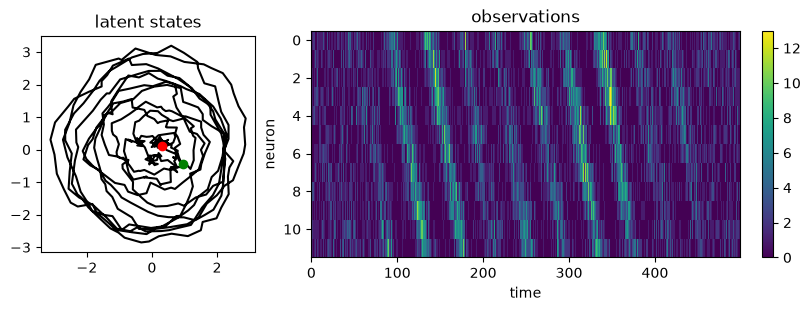

In [2]:
def build_lds_example(
    latent_dim=2,
    num_neurons=12,
    angle=0.15,
    radius=0.995,
    base_rate=1.0,
):
    """Build an LDS example with a damped rotation dynamics."""

    dynamics_matrix = radius * jnp.array(
        [
            [jnp.cos(angle), -jnp.sin(angle)],
            [jnp.sin(angle), jnp.cos(angle)],
        ]
    )

    initial = LatentInitialModel(
        mean=jnp.array([1.5, 0.0]),
        covariance=0.05 * jnp.eye(latent_dim),
    )

    dynamics = LatentDynamicsModel(
        matrix=dynamics_matrix,
        bias=jnp.zeros(latent_dim),
        noise_covariance=0.015 * jnp.eye(latent_dim),
    )

    preferred_angles = jnp.linspace(
        0.0,
        2.0 * jnp.pi,
        num_neurons,
        endpoint=False,
    )

    readout = 0.7 * jnp.stack(
        [
            jnp.cos(preferred_angles),
            jnp.sin(preferred_angles),
        ],
        axis=1,
    )

    emissions = PoissonEmissions(
        readout=readout,
        bias=jnp.full((num_neurons,), jnp.log(base_rate)),
    )

    return Model(
        initial=initial,
        dynamics=dynamics,
        emissions=emissions,
    )


true_model = build_lds_example()

latents_true, observations = true_model.sample(
    num_time_steps=500,
    key=jax.random.key(0),
)


def plot_latent(ax, latents, color='k', **kwargs):
    ax.plot(latents[:, 0], latents[:, 1], color=color, **kwargs)
    ax.scatter(latents[0, 0], latents[0, 1], color='g', zorder=10)
    ax.scatter(latents[-1, 0], latents[-1, 1], color='r', zorder=10)
    ax.set(title='latent states', aspect='equal')


def plot_data(latents, observations):

    f, axs = plt.subplots(
        ncols=2, figsize=(8, 3), constrained_layout=True, gridspec_kw={'width_ratios': [1, 2]}
    )

    ax = axs[0]

    plot_latent(ax, latents)

    ax = axs[1]
    im = ax.imshow(
        observations.T,
        aspect='auto',
        interpolation='none',
    )

    f.colorbar(im, ax=ax)

    ax.set(
        xlabel='time',
        ylabel='neuron',
    )
    ax.set(title='observations')


plot_data(latents_true, observations)

In [3]:
posterior = inference_laplace(true_model, observations)

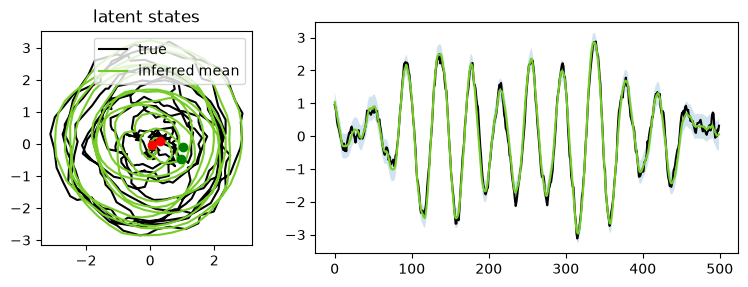

In [4]:
def plot_inference(latents, posterior):
    f, axs = plt.subplots(ncols=2, gridspec_kw={'width_ratios': [1, 2]}, figsize=(9, 3))

    ax = axs[0]
    plot_latent(ax, latents, color='k', label='true')
    plot_latent(ax, posterior.means, color='xkcd:apple green', label='inferred mean')

    ax.legend(loc='upper right')

    ax = axs[1]

    std = jnp.sqrt(posterior.covariances[:, 0, 0])

    ax.plot(latents[:, 0], label='true', color='k')
    ax.plot(posterior.means[:, 0], label='posterior', color='xkcd:apple green')
    ax.fill_between(
        jnp.arange(len(latents)),
        posterior.means[:, 0] - 2 * std,
        posterior.means[:, 0] + 2 * std,
        alpha=0.2,
    )


plot_inference(latents_true, posterior)

In [5]:
initial_models = init.init_pca_poisson_many(
    observations,
    state_dim=2,
    covariance_floors=jnp.logspace(-5, -2, 4),
)

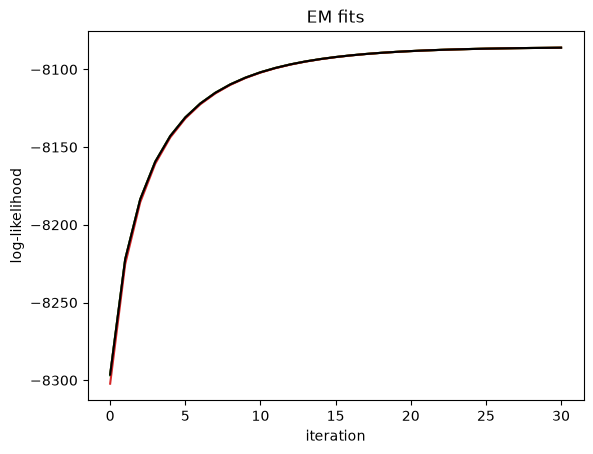

In [6]:
def plot_fits(fits, highlight_idx):
    f, ax = plt.subplots()

    ax.plot(fits.objective_traces.T)

    _, log_likelihoods = fits.get(highlight_idx)

    ax.plot(log_likelihoods, color='k')

    ax.set(
        xlabel='iteration',
        ylabel='log-likelihood',
        title='EM fits',
    )


fits = fit_laplace_em_many(
    initial_models,
    observations,
    num_iters=30,
)

best_idx = fits.best_index()

initial_model = initial_models[best_idx]
fitted_model = fits.get(best_idx)[0]

plot_fits(fits, best_idx)

In [7]:
initial_posterior = inference_laplace(initial_model, observations)
fitted_posterior = inference_laplace(fitted_model, observations)

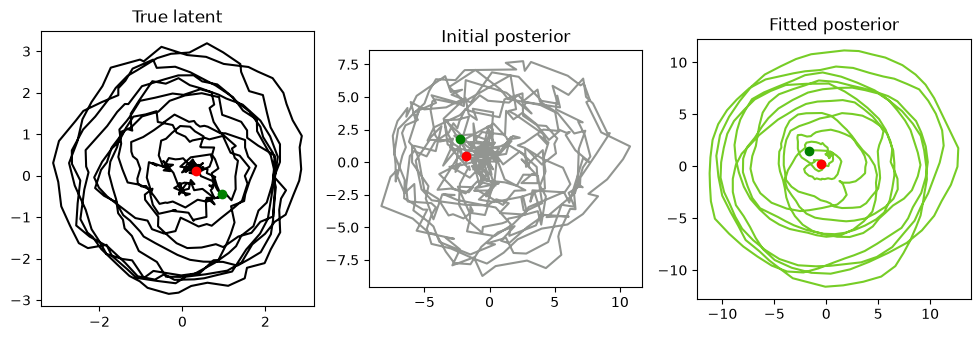

In [8]:
def plot_latent_comparison(latents_true, initial_posterior, fitted_posterior):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    ax = axes[0]
    plot_latent(ax, latents_true)
    ax.set(
        title='True latent',
        aspect='equal',
    )

    ax = axes[1]
    plot_latent(ax, initial_posterior.means, color='xkcd:grey')
    ax.set(
        title='Initial posterior',
        aspect='equal',
    )

    ax = axes[2]
    plot_latent(ax, fitted_posterior.means, color='xkcd:apple green')
    ax.set(
        title='Fitted posterior',
        aspect='equal',
    )


plot_latent_comparison(latents_true, initial_posterior, fitted_posterior)

In [9]:
initial_prediction = initial_model.emissions.rates(initial_posterior.means)
fitted_prediction = fitted_model.emissions.rates(fitted_posterior.means)

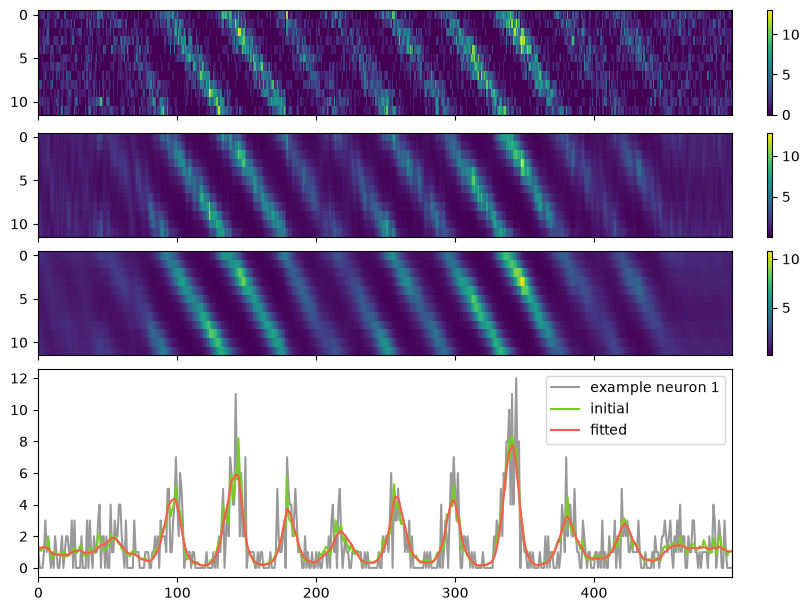

In [10]:
def plot_observations_comparison(
    observations, initial_prediction, fitted_prediction, example_neuron
):
    f, axs = plt.subplots(
        nrows=4,
        sharex='all',
        constrained_layout=True,
        figsize=(8, 6),
        gridspec_kw={'height_ratios': [1, 1, 1, 2]},
    )

    ax = axs[0]
    im = ax.imshow(
        observations.T,
        aspect='auto',
        interpolation='none',
    )

    f.colorbar(im, ax=ax)

    ax = axs[1]
    im = ax.imshow(
        initial_prediction.T,
        aspect='auto',
        interpolation='none',
    )

    f.colorbar(im, ax=ax)

    ax = axs[2]
    im = ax.imshow(
        fitted_prediction.T,
        aspect='auto',
        interpolation='none',
    )

    f.colorbar(im, ax=ax)

    ax = axs[3]
    ax.plot(
        observations[:, example_neuron],
        alpha=0.4,
        label=f'example neuron {example_neuron}',
        color='k',
    )
    ax.plot(initial_prediction[:, example_neuron], label='initial', color='xkcd:apple green')
    ax.plot(fitted_prediction[:, example_neuron], label='fitted', color='xkcd:coral')
    ax.legend()


plot_observations_comparison(observations, initial_prediction, fitted_prediction, example_neuron=1)